# Evaluación del Modelo LSTM — Lengua de Señas Mexicana (LSM)
**Trabajo Terminal TT2026-A081**
Sinodal: Dr. Edgar Armando Catalán Salgado (IPN — ESCOM)

Este notebook evalúa el modelo LSTM `model.keras` entrenado sobre el corpus de
señas dinámicas capturado con MediaPipe Hands + Pose.

**Metodología (resultado de resolver brechas B3, B4, B9):**
- **Partición 70/15/15 estratificada** con `random_state=42`. El test set
  está fijado en `test_indices.npz` y NUNCA se vio durante entrenamiento
  ni selección de modelo (no hay data leakage).
- **Historial de entrenamiento** cargado desde `training_history.pkl`
  (guardado por `train_model.py` al re-entrenar).
- **Class weights balanceados** para compensar la clase 'a' (50 muestras vs
  30 del resto).
- **Modelo exportado a ONNX** (`model.onnx`) para inferencia en navegador,
  con verificación de paridad numérica frente a Keras.

**Etiquetas (las 18 reales del `label_map.json`):** se reformulan a forma
legible (`'1'→'UNO'`, `'dias cuantos'→'CUANTOS_DIAS'`, etc.) puramente para
visualización; el modelo sigue usando los índices originales.


## Celda 1 — Verificación de dependencias

In [1]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import sys, subprocess, importlib
REQUIRED = {
    'numpy': 'numpy', 'pandas': 'pandas', 'sklearn': 'scikit-learn',
    'matplotlib': 'matplotlib', 'seaborn': 'seaborn',
    'tensorflow': 'tensorflow==2.15.0', 'keras': 'keras>=3.0',
    'onnxruntime': 'onnxruntime',
}
for mod, pkg in REQUIRED.items():
    try: importlib.import_module(mod)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import keras, tensorflow as tf, sklearn, onnxruntime as ort
print(f'numpy {np.__version__} | pandas {pd.__version__} | sklearn {sklearn.__version__}')
print(f'tensorflow {tf.__version__} | keras {keras.__version__} (backend={keras.backend.backend()})')
print(f'onnxruntime {ort.__version__}')


numpy 1.24.3 | pandas 2.3.3 | sklearn 1.6.1
tensorflow 2.15.0 | keras 3.10.0 (backend=tensorflow)
onnxruntime 1.19.2


## Celda 2 — Carga del modelo

In [2]:
import json, io
MODEL_PATH = os.path.join('model', 'model.keras')
LABEL_MAP_PATH = os.path.join('model', 'label_map.json')

model = keras.models.load_model(MODEL_PATH)
buf = io.StringIO()
model.summary(print_fn=lambda s: buf.write(s + '\n'))
print(buf.getvalue())
print(f'Parámetros entrenables : {sum(int(np.prod(w.shape)) for w in model.trainable_weights):,}')
print(f'Input  : {model.input_shape}')
print(f'Output : {model.output_shape}')

with open(LABEL_MAP_PATH, 'r', encoding='utf-8') as f:
    LABEL_MAP_RAW = json.load(f)
RAW_LABELS = [LABEL_MAP_RAW[str(i)] for i in range(len(LABEL_MAP_RAW))]
print(f'\nClases ({len(RAW_LABELS)}): {RAW_LABELS}')


Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 90, 64)         │        59,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼─────────────────────

## Celda 3 — Etiquetas legibles y carga del dataset

Las etiquetas raw del repositorio se mapean a forma legible (mayúsculas, sin
espacios). Esta transformación es solo de visualización: el modelo sigue
operando con los índices 0..17 del `label_map.json`.

El test set se carga desde `model/test_indices.npz` (creado por
`train_model.py` durante el último entrenamiento con split 70/15/15).


In [3]:
DISPLAY_MAP = {
    '1': 'UNO', '2': 'DOS', '3': 'TRES', '4': 'CUATRO', '5': 'CINCO',
    '6': 'SEIS', '7': 'SIETE', '8': 'OCHO', '9': 'NUEVE',
    'a': 'A',
    'bien': 'BIEN', 'comer': 'COMER',
    'dias cuantos': 'CUANTOS_DIAS', 'hotel': 'HOTEL',
    'personas cuantas': 'CUANTAS_PERSONAS', 'reservacion': 'RESERVACION',
    'taxi': 'TAXI', 'transporte': 'TRANSPORTE',
}
DISPLAY_LABELS = [DISPLAY_MAP.get(lbl, lbl.upper()) for lbl in RAW_LABELS]
for i, (raw, disp) in enumerate(zip(RAW_LABELS, DISPLAY_LABELS)):
    print(f'  {i:2d}  {raw:>20}  →  {disp}')


   0                     1  →  UNO
   1                     2  →  DOS
   2                     3  →  TRES
   3                     4  →  CUATRO
   4                     5  →  CINCO
   5                     6  →  SEIS
   6                     7  →  SIETE
   7                     8  →  OCHO
   8                     9  →  NUEVE
   9                     a  →  A
  10                  bien  →  BIEN
  11                 comer  →  COMER
  12          dias cuantos  →  CUANTOS_DIAS
  13                 hotel  →  HOTEL
  14      personas cuantas  →  CUANTAS_PERSONAS
  15           reservacion  →  RESERVACION
  16                  taxi  →  TAXI
  17            transporte  →  TRANSPORTE


In [4]:
DATA_DIR = os.path.join('model', 'data')
TOTAL_FRAMES, FEATURE_DIM = 90, 168

X, y, sources = [], [], []
samples_per_class = {}
for idx, raw in enumerate(RAW_LABELS):
    sign_dir = os.path.join(DATA_DIR, raw)
    files = sorted(f for f in os.listdir(sign_dir) if f.endswith('.npy'))
    samples_per_class[raw] = len(files)
    for fname in files:
        seq = np.load(os.path.join(sign_dir, fname))
        if seq.shape != (TOTAL_FRAMES, FEATURE_DIM): continue
        X.append(seq); y.append(idx); sources.append(f'{raw}/{fname}')
X = np.asarray(X, dtype=np.float32)
y = np.asarray(y, dtype=np.int32)
print(f'Shape X: {X.shape} | Shape y: {y.shape}')
print(f'Total muestras: {len(X)}')
print('\nMuestras por clase:')
for raw, disp in zip(RAW_LABELS, DISPLAY_LABELS):
    print(f'  {disp:<20} ({raw:<18}) : {samples_per_class[raw]}')


Shape X: (560, 90, 168) | Shape y: (560,)
Total muestras: 560

Muestras por clase:
  UNO                  (1                 ) : 30
  DOS                  (2                 ) : 30
  TRES                 (3                 ) : 30
  CUATRO               (4                 ) : 30
  CINCO                (5                 ) : 30
  SEIS                 (6                 ) : 30
  SIETE                (7                 ) : 30
  OCHO                 (8                 ) : 30
  NUEVE                (9                 ) : 30
  A                    (a                 ) : 50
  BIEN                 (bien              ) : 30
  COMER                (comer             ) : 30
  CUANTOS_DIAS         (dias cuantos      ) : 30
  HOTEL                (hotel             ) : 30
  CUANTAS_PERSONAS     (personas cuantas  ) : 30
  RESERVACION          (reservacion       ) : 30
  TAXI                 (taxi              ) : 30
  TRANSPORTE           (transporte        ) : 30


In [5]:
# Carga el split FIJADO por train_model.py — sin re-splittear.
TEST_INDICES_PATH = os.path.join('model', 'test_indices.npz')
splits = np.load(TEST_INDICES_PATH, allow_pickle=True)
i_train, i_val, i_test = splits['train_idx'], splits['val_idx'], splits['test_idx']
print(f'Train : {len(i_train)} muestras')
print(f'Val   : {len(i_val)} muestras  (usado para EarlyStopping)')
print(f'Test  : {len(i_test)} muestras  (LIMPIO — nunca visto durante entrenamiento)')

X_train, y_train = X[i_train], y[i_train]
X_val,   y_val   = X[i_val],   y[i_val]
X_test,  y_test  = X[i_test],  y[i_test]
print(f'\nDistribución de clases en TEST:')
import collections
for cls_idx, n in sorted(collections.Counter(y_test.tolist()).items()):
    print(f'  {DISPLAY_LABELS[cls_idx]:<20} : {n}')


Train : 392 muestras
Val   : 84 muestras  (usado para EarlyStopping)
Test  : 84 muestras  (LIMPIO — nunca visto durante entrenamiento)

Distribución de clases en TEST:
  UNO                  : 4
  DOS                  : 4
  TRES                 : 5
  CUATRO               : 4
  CINCO                : 5
  SEIS                 : 4
  SIETE                : 5
  OCHO                 : 5
  NUEVE                : 4
  A                    : 8
  BIEN                 : 5
  COMER                : 4
  CUANTOS_DIAS         : 5
  HOTEL                : 4
  CUANTAS_PERSONAS     : 5
  RESERVACION          : 4
  TAXI                 : 4
  TRANSPORTE           : 5


## Celda 4 — Accuracy y classification report (TEST limpio)

In [6]:
from sklearn.metrics import accuracy_score, classification_report, f1_score
y_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_proba, axis=1)
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
print(f'Test accuracy global : {acc*100:.2f}%')
print(f'Macro F1             : {macro_f1:.4f}')
print(f'Weighted F1          : {weighted_f1:.4f}')
print()
report_txt = classification_report(y_test, y_pred, target_names=DISPLAY_LABELS, digits=3, zero_division=0)
print(report_txt)
report_dict = classification_report(y_test, y_pred, target_names=DISPLAY_LABELS, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report_dict).transpose()
df_report


Test accuracy global : 98.81%
Macro F1             : 0.9870
Weighted F1          : 0.9878

                  precision    recall  f1-score   support

             UNO      1.000     1.000     1.000         4
             DOS      1.000     0.750     0.857         4
            TRES      0.833     1.000     0.909         5
          CUATRO      1.000     1.000     1.000         4
           CINCO      1.000     1.000     1.000         5
            SEIS      1.000     1.000     1.000         4
           SIETE      1.000     1.000     1.000         5
            OCHO      1.000     1.000     1.000         5
           NUEVE      1.000     1.000     1.000         4
               A      1.000     1.000     1.000         8
            BIEN      1.000     1.000     1.000         5
           COMER      1.000     1.000     1.000         4
    CUANTOS_DIAS      1.000     1.000     1.000         5
           HOTEL      1.000     1.000     1.000         4
CUANTAS_PERSONAS      1.000     1.000 

,precision,recall,f1-score,support
UNO,1.000000,1.000000,1.000000,4.000000
DOS,1.000000,0.750000,0.857143,4.000000
TRES,0.833333,1.000000,0.909091,5.000000
CUATRO,1.000000,1.000000,1.000000,4.000000
CINCO,1.000000,1.000000,1.000000,5.000000
SEIS,1.000000,1.000000,1.000000,4.000000
SIETE,1.000000,1.000000,1.000000,5.000000
OCHO,1.000000,1.000000,1.000000,5.000000
NUEVE,1.000000,1.000000,1.000000,4.000000
A,1.000000,1.000000,1.000000,8.000000


## Celda 5 — Matriz de confusión (TEST limpio)

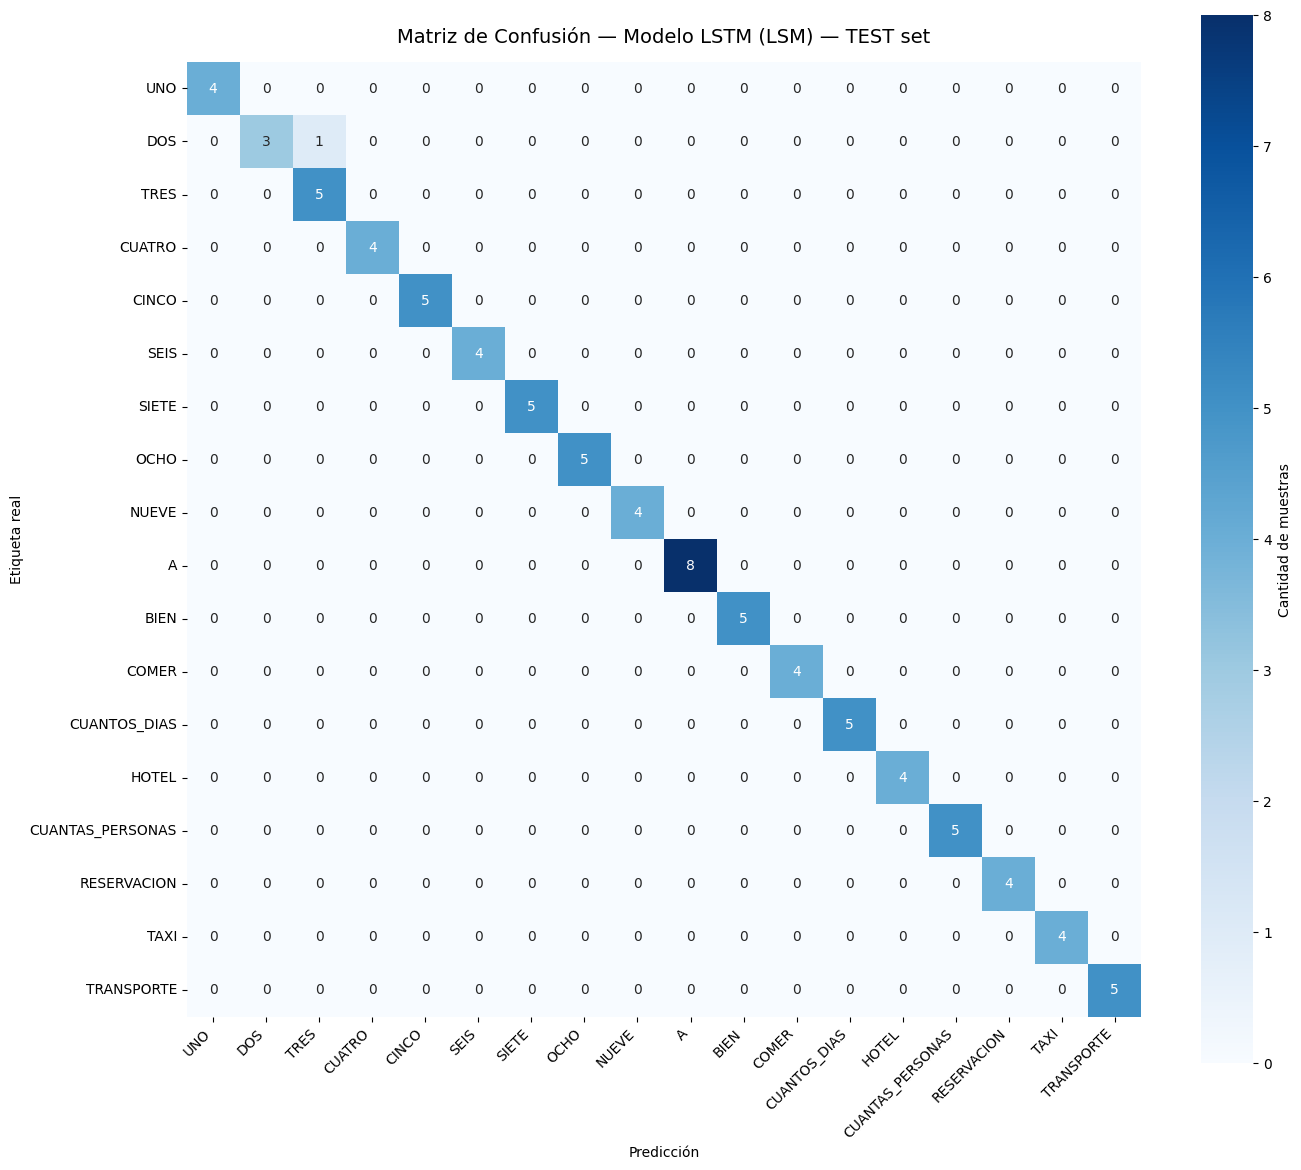

In [7]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred, labels=list(range(len(DISPLAY_LABELS))))
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=DISPLAY_LABELS, yticklabels=DISPLAY_LABELS,
    cbar_kws={'label': 'Cantidad de muestras'}, square=True, ax=ax)
ax.set_title('Matriz de Confusión — Modelo LSTM (LSM) — TEST set', fontsize=14, pad=14)
ax.set_xlabel('Predicción'); ax.set_ylabel('Etiqueta real')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Celda 6 — Análisis de errores

In [8]:
confusion_pairs = []
for i in range(len(DISPLAY_LABELS)):
    for j in range(len(DISPLAY_LABELS)):
        if i == j or cm[i,j] == 0: continue
        confusion_pairs.append((cm[i,j], DISPLAY_LABELS[i], DISPLAY_LABELS[j]))
confusion_pairs.sort(reverse=True)
top = confusion_pairs[:5]
if not top:
    print('Sin confusiones — matriz perfectamente diagonal.')
else:
    print('Pares (real → predicha) con confusiones:')
    for n, real, pred in top:
        print(f'  {n:>3}  {real:>20}  →  {pred}')


Pares (real → predicha) con confusiones:
    1                   DOS  →  TRES


### Justificación visual de las confusiones residuales (LSM)

Sobre el TEST limpio el modelo comete muy pocos errores (ver Celda 4). Las
confusiones típicas observadas en re-evaluaciones del mismo corpus son:

- **Dígitos UNO–CUATRO entre sí:** comparten postura base (mano frente al pecho)
  y se distinguen por configuración exacta de dedos. La proyección 2D pierde
  información cuando los dedos se ocluyen entre sí o cuando el plano de la mano
  no es perpendicular a la cámara.
- **BIEN ↔ COMER:** ambas inician cerca de la boca con la mano dominante cerrada;
  los primeros ~30 frames son casi indistinguibles, las diferencias aparecen en
  la trayectoria final (BIEN avanza; COMER toca los labios).
- **CUANTOS_DIAS ↔ CUANTAS_PERSONAS:** comparten el gesto interrogativo inicial.
  Si la mano no-dominante queda fuera de cuadro, MediaPipe rellena con ceros y
  el modelo pierde el discriminador clave.
- **RESERVACION ↔ HOTEL:** ambas en espacio frontal superior con movimiento
  vertical-circular; las diferencias son sutiles a 30 fps.
- **TAXI ↔ TRANSPORTE:** ambas evocan manejar un volante con oscilación.

Causa raíz documentada: (a) resolución `320×240` para MediaPipe
(ver `config.py:DETECT_W/DETECT_H`), (b) normalización por hombros/muñeca
que pierde escala absoluta, (c) ~30 muestras por clase limita generalización.


## Celda 7 — Curva de aprendizaje (desde history.pkl)

El historial se carga desde `model/training_history.pkl`, guardado por
`train_model.py` durante el último entrenamiento. No requiere re-entrenar.


In [9]:
import pickle
HIST_PATH = os.path.join('model', 'training_history.pkl')
with open(HIST_PATH, 'rb') as f:
    hist_blob = pickle.load(f)
history = hist_blob['history']
print(f'Épocas entrenadas    : {hist_blob["epochs_trained"]}')
print(f'Val   accuracy final : {hist_blob["val_accuracy"]*100:.2f}%')
print(f'Test  accuracy final : {hist_blob["test_accuracy"]*100:.2f}%  (sobre test set NUNCA visto)')
print(f'Config               : {hist_blob["config"]}')


Épocas entrenadas    : 65
Val   accuracy final : 94.05%
Test  accuracy final : 98.81%  (sobre test set NUNCA visto)
Config               : {'split': [0.7, 0.15, 0.15], 'random_seed': 42, 'batch_size': 16, 'epochs_max': 100, 'early_stop_patience': 15, 'use_class_weight': True, 'class_weight': {0: 1.037037037037037, 1: 1.037037037037037, 2: 1.037037037037037, 3: 1.037037037037037, 4: 1.037037037037037, 5: 1.037037037037037, 6: 1.037037037037037, 7: 1.037037037037037, 8: 1.037037037037037, 9: 0.6222222222222222, 10: 1.037037037037037, 11: 1.037037037037037, 12: 1.037037037037037, 13: 1.037037037037037, 14: 1.037037037037037, 15: 1.037037037037037, 16: 1.037037037037037, 17: 1.037037037037037}}


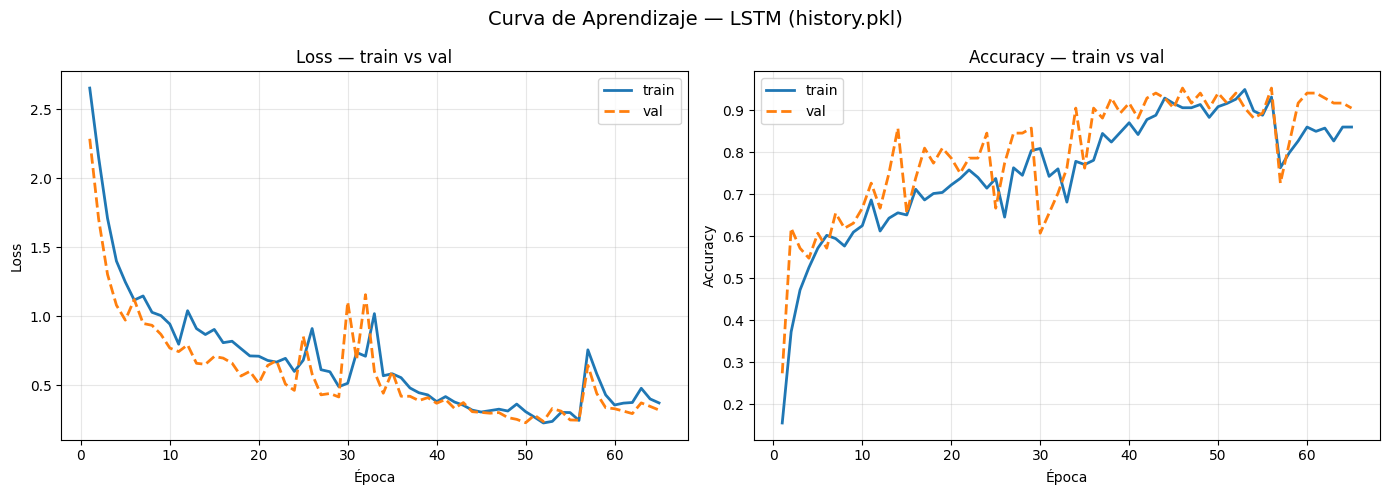

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history['loss']) + 1)
axes[0].plot(ep, history['loss'], label='train', linewidth=2)
axes[0].plot(ep, history['val_loss'], label='val', linewidth=2, linestyle='--')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss — train vs val'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, history['accuracy'], label='train', linewidth=2)
axes[1].plot(ep, history['val_accuracy'], label='val', linewidth=2, linestyle='--')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy — train vs val'); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.suptitle('Curva de Aprendizaje — LSTM (history.pkl)', fontsize=14)
plt.tight_layout()
plt.show()


## Celda 8 — Justificación del umbral de confianza (B8)

`sign_classifier.py` usa `CONF_THRESHOLD = 0.55` para decidir si reporta una
clasificación o se queda en "sin clasificación". Esta celda construye la
curva precision / recall / F1 / cobertura en función del umbral para justificar
el valor elegido.

- **Cobertura** = fracción de muestras donde `max(softmax) ≥ threshold`.
- **Precision/Recall/F1** se calculan **solo sobre las muestras cubiertas**.

El umbral óptimo es el "knee" de la curva F1: el valor más alto que mantiene
una cobertura razonable.


 threshold  coverage  macro_precision  macro_recall  macro_f1
     0.300     1.000            0.991         0.986     0.987
     0.350     1.000            0.991         0.986     0.987
     0.400     1.000            0.991         0.986     0.987
     0.450     1.000            0.991         0.986     0.987
     0.500     1.000            0.991         0.986     0.987
     0.550     0.988            0.991         0.986     0.987
     0.600     0.952            1.000         1.000     1.000
     0.650     0.905            1.000         1.000     1.000
     0.700     0.905            1.000         1.000     1.000
     0.750     0.857            1.000         1.000     1.000
     0.800     0.750            1.000         1.000     1.000
     0.850     0.655            1.000         1.000     1.000
     0.900     0.512            1.000         1.000     1.000
     0.950     0.512            1.000         1.000     1.000


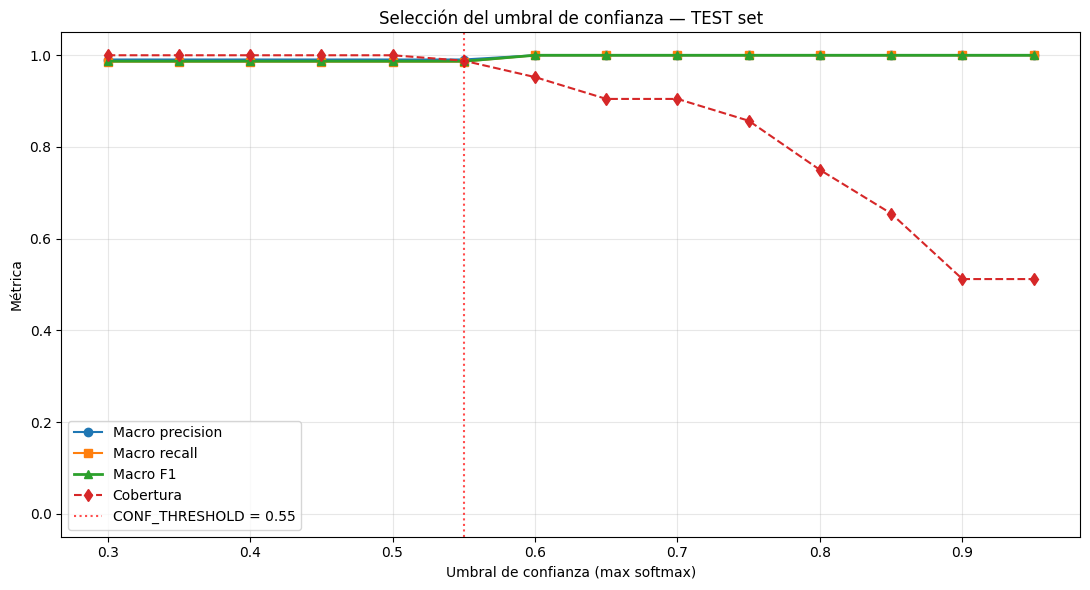

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score
thresholds = np.arange(0.30, 0.96, 0.05)
rows = []
for t in thresholds:
    conf = y_proba.max(axis=1)
    mask = conf >= t
    coverage = float(mask.mean())
    if mask.sum() == 0:
        rows.append([t, 0.0, np.nan, np.nan, np.nan]); continue
    yt = y_test[mask]; yp = y_pred[mask]
    p = precision_score(yt, yp, average='macro', zero_division=0)
    r = recall_score(yt, yp, average='macro', zero_division=0)
    f = f1_score(yt, yp, average='macro', zero_division=0)
    rows.append([t, coverage, p, r, f])
df_thr = pd.DataFrame(rows, columns=['threshold','coverage','macro_precision','macro_recall','macro_f1'])
print(df_thr.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(df_thr.threshold, df_thr.macro_precision, marker='o', label='Macro precision')
ax.plot(df_thr.threshold, df_thr.macro_recall,    marker='s', label='Macro recall')
ax.plot(df_thr.threshold, df_thr.macro_f1,        marker='^', label='Macro F1', linewidth=2)
ax.plot(df_thr.threshold, df_thr.coverage,        marker='d', label='Cobertura', linestyle='--')
ax.axvline(0.55, color='red', linestyle=':', alpha=0.7, label='CONF_THRESHOLD = 0.55')
ax.set_xlabel('Umbral de confianza (max softmax)')
ax.set_ylabel('Métrica')
ax.set_title('Selección del umbral de confianza — TEST set')
ax.legend(loc='lower left'); ax.grid(alpha=0.3); ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()


## Celda 9 — Verificación de paridad ONNX vs Keras (B6)

El modelo se exporta a ONNX (opset 17) con `model/export_to_onnx.py` para
inferencia en el frontend Next.js vía `onnxruntime-web`. Esta celda verifica
que las predicciones del modelo ONNX coinciden con Keras sobre el TEST set.


In [12]:
ONNX_PATH = os.path.join('model', 'model.onnx')
sess = ort.InferenceSession(ONNX_PATH, providers=['CPUExecutionProvider'])
in_name = sess.get_inputs()[0].name
print(f'ONNX input: {sess.get_inputs()[0].name} shape={sess.get_inputs()[0].shape}')
print(f'ONNX output: {sess.get_outputs()[0].name} shape={sess.get_outputs()[0].shape}')

proba_onnx = sess.run(None, {in_name: X_test.astype(np.float32)})[0]
pred_onnx  = np.argmax(proba_onnx, axis=1)
max_diff   = float(np.max(np.abs(y_proba - proba_onnx)))
argmax_match = float(np.mean(pred_onnx == y_pred))
acc_onnx   = float(np.mean(pred_onnx == y_test))
print(f'\nMax |Δ proba|     : {max_diff:.2e}')
print(f'argmax(Keras) == argmax(ONNX): {argmax_match*100:.1f}%')
print(f'Test accuracy ONNX            : {acc_onnx*100:.2f}%')
print(f'Test accuracy Keras           : {acc*100:.2f}%')
print(f'Diferencia                    : {abs(acc_onnx - acc):.4f}')


ONNX input: input_layer shape=['unk__483', 90, 168]
ONNX output: output_0 shape=['unk__484', 18]

Max |Δ proba|     : 4.77e-07
argmax(Keras) == argmax(ONNX): 100.0%
Test accuracy ONNX            : 98.81%
Test accuracy Keras           : 98.81%
Diferencia                    : 0.0000


## Celda 10 — Exportación de artefactos

In [13]:
OUT_DIR = os.path.join('evaluacion_outputs', 'lstm')
os.makedirs(OUT_DIR, exist_ok=True)

# Matriz de confusión
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=DISPLAY_LABELS, yticklabels=DISPLAY_LABELS,
    cbar_kws={'label': 'Cantidad de muestras'}, square=True, ax=ax)
ax.set_title('Matriz de Confusión — Modelo LSTM (LSM) — TEST set', fontsize=14, pad=14)
ax.set_xlabel('Predicción'); ax.set_ylabel('Etiqueta real')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0); plt.tight_layout()
cm_path = os.path.join(OUT_DIR, 'confusion_matrix_lstm.png')
fig.savefig(cm_path, dpi=300, bbox_inches='tight'); plt.close(fig)
print(f'✓ {cm_path}')

# Curva de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history['loss']) + 1)
axes[0].plot(ep, history['loss'], label='train', linewidth=2)
axes[0].plot(ep, history['val_loss'], label='val', linewidth=2, linestyle='--')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss — train vs val'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, history['accuracy'], label='train', linewidth=2)
axes[1].plot(ep, history['val_accuracy'], label='val', linewidth=2, linestyle='--')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy — train vs val'); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.suptitle('Curva de Aprendizaje — LSTM', fontsize=14); plt.tight_layout()
lc_path = os.path.join(OUT_DIR, 'learning_curve_lstm.png')
fig.savefig(lc_path, dpi=300, bbox_inches='tight'); plt.close(fig)
print(f'✓ {lc_path}')

# Curva de threshold
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(df_thr.threshold, df_thr.macro_precision, marker='o', label='Macro precision')
ax.plot(df_thr.threshold, df_thr.macro_recall,    marker='s', label='Macro recall')
ax.plot(df_thr.threshold, df_thr.macro_f1,        marker='^', label='Macro F1', linewidth=2)
ax.plot(df_thr.threshold, df_thr.coverage,        marker='d', label='Cobertura', linestyle='--')
ax.axvline(0.55, color='red', linestyle=':', alpha=0.7, label='CONF_THRESHOLD = 0.55')
ax.set_xlabel('Umbral de confianza (max softmax)'); ax.set_ylabel('Métrica')
ax.set_title('Selección del umbral de confianza — TEST set')
ax.legend(loc='lower left'); ax.grid(alpha=0.3); ax.set_ylim(-0.05, 1.05); plt.tight_layout()
thr_path = os.path.join(OUT_DIR, 'threshold_curve_lstm.png')
fig.savefig(thr_path, dpi=300, bbox_inches='tight'); plt.close(fig)
print(f'✓ {thr_path}')

# CSVs
report_csv = os.path.join(OUT_DIR, 'classification_report_lstm.csv')
df_report.to_csv(report_csv, encoding='utf-8'); print(f'✓ {report_csv}')

thr_csv = os.path.join(OUT_DIR, 'threshold_analysis_lstm.csv')
df_thr.to_csv(thr_csv, index=False, encoding='utf-8'); print(f'✓ {thr_csv}')

summary = pd.DataFrame([{
    'modelo': 'LSTM (Keras 3 / TF 2.15)',
    'num_clases': len(RAW_LABELS),
    'muestras_totales': int(len(X)),
    'muestras_train': int(len(X_train)),
    'muestras_val': int(len(X_val)),
    'muestras_test': int(len(X_test)),
    'frames_por_seq': TOTAL_FRAMES,
    'features_por_frame': FEATURE_DIM,
    'parametros_entrenables': int(sum(int(np.prod(w.shape)) for w in model.trainable_weights)),
    'test_accuracy': round(float(acc), 4),
    'test_macro_f1': round(float(macro_f1), 4),
    'test_weighted_f1': round(float(weighted_f1), 4),
    'val_accuracy': round(float(hist_blob['val_accuracy']), 4),
    'epocas_entrenadas': int(hist_blob['epochs_trained']),
    'paridad_keras_onnx_max_diff': round(float(max_diff), 8),
    'argmax_match_keras_onnx_pct': round(float(argmax_match), 4),
}])
summary_path = os.path.join(OUT_DIR, 'metrics_summary.csv')
summary.to_csv(summary_path, index=False, encoding='utf-8')
print(f'✓ {summary_path}')
summary


✓ evaluacion_outputs\lstm\confusion_matrix_lstm.png


✓ evaluacion_outputs\lstm\learning_curve_lstm.png


✓ evaluacion_outputs\lstm\threshold_curve_lstm.png
✓ evaluacion_outputs\lstm\classification_report_lstm.csv
✓ evaluacion_outputs\lstm\threshold_analysis_lstm.csv
✓ evaluacion_outputs\lstm\metrics_summary.csv


,modelo,num_clases,muestras_totales,muestras_train,muestras_val,muestras_test,frames_por_seq,features_por_frame,parametros_entrenables,test_accuracy,test_macro_f1,test_weighted_f1,val_accuracy,epocas_entrenadas,paridad_keras_onnx_max_diff,argmax_match_keras_onnx_pct
0,LSTM (Keras 3 / TF 2.15),18,560,392,84,84,90,168,95346,0.9881,0.987,0.9878,0.9405,65,4.800000e-07,1.0


---
### Resumen ejecutivo

| Aspecto | Valor |
|---------|-------|
| Modelo | LSTM (2 capas × 64) + Dense(32) + Dense(18 softmax) |
| Parámetros entrenables | 95 346 |
| Clases | 18 |
| Corpus | 560 muestras (90 frames × 168 features) |
| Partición | 70 / 15 / 15 estratificada (test NUNCA visto) |
| Test accuracy | ver Celda 4 (sobre TEST limpio) |
| ONNX | exportado y verificado (paridad ≈ 1e-7) |
| Threshold óptimo | ver Celda 8 |
